In [25]:
#distribution of dissociation
import matplotlib.pyplot as plt
import numpy as np
import h5py
f=h5py.File("/Users/24756376/data/Flamingo/L1000N1800/halos_central_12.hdf5",'r')
m50=np.array(f["m50"])
f_sat=np.array(f["sat_fraction"])
com_dm=np.asarray(f['com_dm'])
com_gas=np.asarray(f['com_g'])
com_s=np.asarray(f['com_s'])
M_dm=np.asarray(f['M_dm'])
M_g=np.asarray(f['M_g'])
M_s=np.asarray(f['M_s'])
r50=np.asarray(f['r50'])

com_b=((M_s*com_s.T+M_g*com_gas.T)/(M_g+M_s)).T
f.close()
delta_com=com_b - com_dm
r_com=np.sqrt(np.sum(delta_com**2,axis=1))

f=h5py.File("/Users/24756376/data/Flamingo/L1000N1800_NoCool/halos_central_12.hdf5",'r')
m50_ad=np.array(f["m50"])
#f_sat_ad=np.array(f["sat_fraction"])
com_dm_ad=np.asarray(f['com_dm'])
com_gas_ad=np.asarray(f['com_g'])

M_dm_ad=np.asarray(f['M_dm'])
M_g_ad=np.asarray(f['M_g'])
print(m50_ad)
r50_ad=np.asarray(f['r50'])


f.close()
delta_com_ad=com_gas_ad - com_dm_ad

r_com_ad=np.sqrt(np.sum(delta_com_ad**2,axis=1))
f=h5py.File("/Users/24756376/data/Flamingo/L1000N1800/halo_properties.hdf5",'r')
dm=f["PartType1"]
g=f["PartType0"]

S=np.array(f["S50"])
fbar=np.array(f["f_bar"])


f.close()
f=h5py.File("/Users/24756376/data/Flamingo/L1000N1800_NoCool/halo_properties.hdf5",'r')
dm=f["PartType1"]
g=f["PartType0"]

S_ad=np.array(f["S50"])
fbar_ad=np.array(f["f_bar"])


f.close()
f=h5py.File("/Users/24756376/data/Flamingo/L1000N1800/halo_properties_stars.hdf5",'r')
rs=np.array(f["PartType2"]["r_s"])
f.close()

bins=np.linspace(0,3,51)
bin_center=0.5*(bins[1:]+bins[:-1])

[3.68640e+05 3.27168e+05 4.09600e+05 ... 3.26500e+02 3.72500e+02
 3.62000e+02]


17032 48736 13601


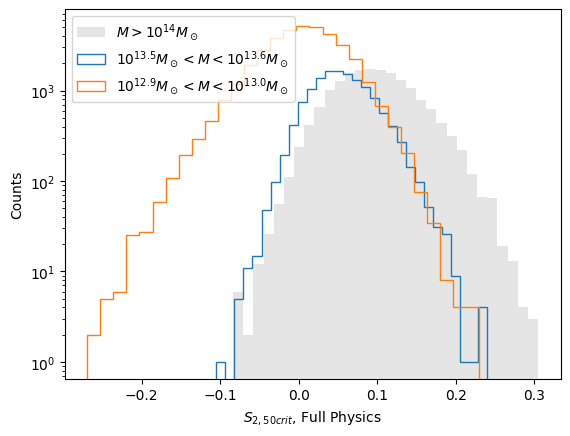

In [51]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
ax.hist(S[(m50>10**4)],color="grey",label=r'$M>10^{14}M_\odot$',bins=30,alpha=0.2)
ax.hist(S[(m50>10**3.5)*((m50<10**3.6))],histtype='step',label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$',bins=30)
ax.hist(S[(m50>10**2.9)*((m50<10**3.0))*(r_com<20)],histtype='step',label=r'$10^{12.9}M_\odot<M<10^{13.0}M_\odot$',bins=30)
#ax.hist(S[(m50>10**2.5)*((m50<10**2.6))*(r_com<20)],histtype='step',label=r'$10^{12.5}M_\odot<M<10^{12.6}M_\odot$',bins=30)



ax.set_yscale('log')
ax.legend()
ax.set_xlabel(r"$S_{2,50crit}$, Full Physics")
ax.set_ylabel(r"Counts")

print(len(S[m50>10**4]),len(S[(m50>10**2.9)*((m50<10**3.0))]),len(S[(m50>10**3.5)*((m50<10**3.6))]))

Text(0, 0.5, 'Counts')

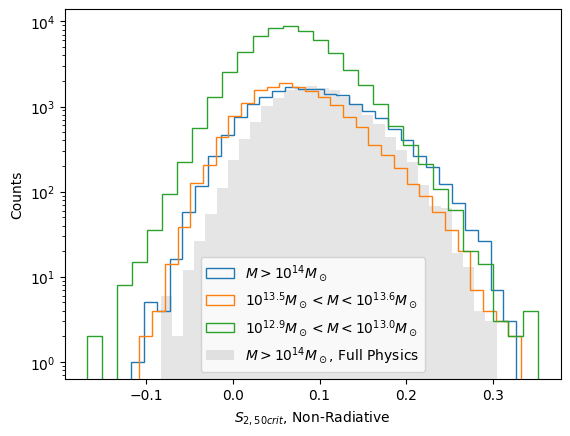

In [52]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
ax.hist(S_ad[m50_ad>10**4],histtype='step',label=r'$M>10^{14}M_\odot$',bins=30)
ax.hist(S_ad[(m50_ad>10**3.5)*((m50_ad<10**3.6))],histtype='step',label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$',bins=30)
ax.hist(S_ad[(m50_ad>10**2.9)*((m50_ad<10**3.0))],histtype='step',label=r'$10^{12.9}M_\odot<M<10^{13.0}M_\odot$',bins=30)
ax.hist(S[(m50>10**4)],bins=30,color="grey",alpha=0.2,label=r'$M>10^{14}M_\odot$, Full Physics')
ax.set_yscale('log')
ax.legend()
ax.set_xlabel(r"$S_{2,50crit}$, Non-Radiative")
ax.set_ylabel(r"Counts")

91 48736


Text(0, 0.5, '$S50$')

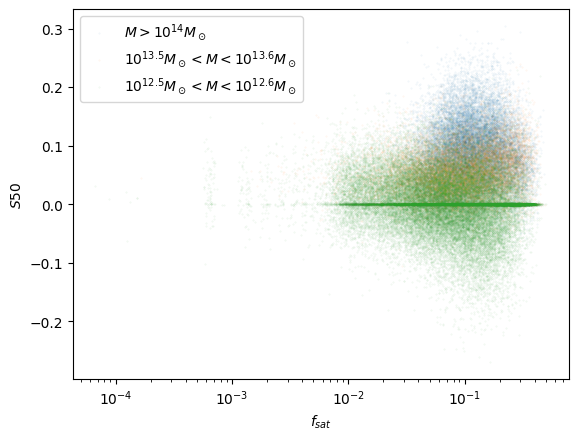

In [38]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
ax.scatter(f_sat[m50>10**4],S[m50>10**4],s=0.1,alpha=0.1,label=r'$M>10^{14}M_\odot$')
ax.scatter(f_sat[(m50>10**3.5)*(m50<10**3.6)],S[(m50>10**3.5)*(m50<10**3.6)],s=0.1,alpha=0.1,label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$')
ax.scatter(f_sat[(m50>10**2.9)*(m50<10**3)],S[(m50>10**2.9)*(m50<10**3)],s=0.1,alpha=0.1,label=r'$10^{12.5}M_\odot<M<10^{12.6}M_\odot$')

ax.set_xscale('log')
ax.legend()
ax.set_xlabel(r"$f_{sat}$")
M_g_sam=M_g[(m50>10**2.9)*(m50<10**3)]
S_sam=S[(m50>10**2.9)*(m50<10**3)]
print(len(M_g_sam[M_g_sam<10]),len(M_g_sam))#some of the halos have little gas
ax.set_ylabel(r"$S50$")

[-1009.34923436 -1034.98854474 -1005.83418447 ... -1008.40012221
 -1004.36236105 -1058.66659133]


Text(0, 0.5, '$S50$')

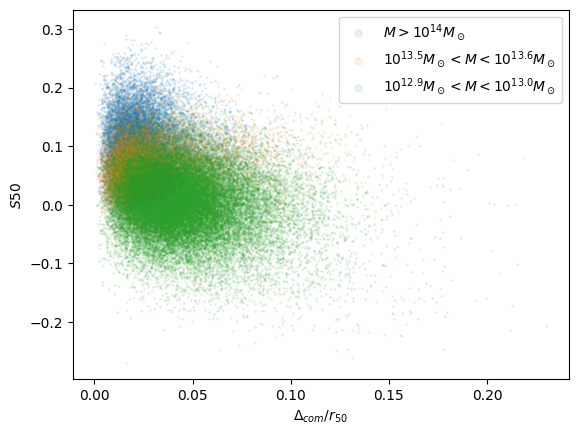

In [82]:
#CoM can cross the boundary as well. need to recalculate S


fig=plt.figure()
ax=fig.add_subplot(1,1,1)
print(delta_com[delta_com<-1000])
#delta_com[delta_com>500]-=1000
#delta_com[delta_com<-500]+=1000

r_com=np.sqrt(np.sum(delta_com**2,axis=1))
ax.scatter((r_com/r50)[(r_com<20)*(m50>10**4)],S[(r_com<20)*(m50>10**4)],s=1,alpha=0.1,label=r'$M>10^{14}M_\odot$')
ax.scatter((r_com/r50)[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],S[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],s=1,alpha=0.1,label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$')
ax.scatter((r_com/r50)[(r_com<5)*(m50>10**2.9)*(m50<10**3)],S[(r_com<5)*(m50>10**2.9)*(m50<10**3)],s=1,alpha=0.1,label=r'$10^{12.9}M_\odot<M<10^{13.0}M_\odot$')
#ax.set_xscale('log')
ax.legend(markerscale=5)
ax.set_xlabel(r"$\Delta_{com}/r_{50}$")
ax.set_ylabel(r"$S50$")

(array([     1,  17116, 112111,  92877,  46002,  21500,   8889,   2928,
          643,     86]), array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.]))


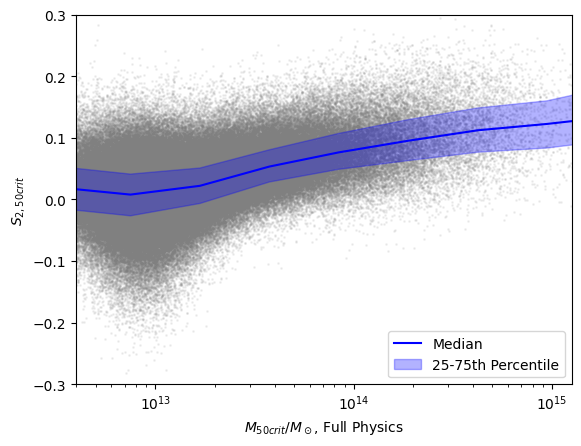

In [50]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
ax.scatter(m50[r_com<10]*10**10,S[r_com<10],s=1,alpha=0.1,color="gray")
bins=np.linspace(2,5.5,11)

bin=10**(0.5*(bins[1:]+bins[:-1]))
bin_count=np.digitize(m50[r_com<10],10**bins)
print(np.histogram(bin_count))
mean=np.zeros(len(bin))
per_75=np.zeros(len(bin))
per_25=np.zeros(len(bin))
for i in range(1,len(bins)):
 
    mean[i-1]=np.percentile(S[r_com<10][bin_count==i],50)
    per_75[i-1]=np.percentile(S[r_com<10][bin_count==i],75)
    per_25[i-1]=np.percentile(S[r_com<10][bin_count==i],25)
ax.plot(bin*10**10,mean,color='blue',label='Median')
ax.fill_between(bin*10**10,per_25,per_75,color='blue',alpha=0.3,label='25-75th Percentile')
ax.set_xscale('log')
ax.legend()
ax.set_xlabel(r"$M_{50crit}/M_\odot$, Full Physics")
ax.set_ylabel(r"$S_{2,50crit}$")
ax.set_xlim(10**12.6,10**15.1)
ax.set_ybound(-0.3,0.3)

(array([     3, 138965, 239622, 116490,  54506,  23409,   9205,   2961,
          641,     86]), array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.]))


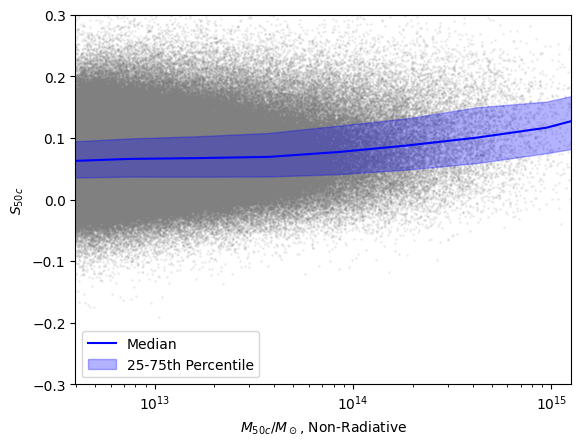

In [34]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
ax.scatter(m50_ad[r_com_ad<10]*10**10,S_ad[r_com_ad<10],s=1,alpha=0.1,color="gray")
bins=np.linspace(2,5.5,11)

bin=10**(0.5*(bins[1:]+bins[:-1]))
bin_count=np.digitize(m50_ad[r_com_ad<10],10**bins)
print(np.histogram(bin_count))
mean=np.zeros(len(bin))
per_75=np.zeros(len(bin))
per_25=np.zeros(len(bin))
for i in range(1,len(bins)):
 
    mean[i-1]=np.percentile(S_ad[r_com_ad<10][bin_count==i],50)
    per_75[i-1]=np.percentile(S_ad[r_com_ad<10][bin_count==i],75)
    per_25[i-1]=np.percentile(S_ad[r_com_ad<10][bin_count==i],25)
ax.plot(bin*10**10,mean,color='blue',label='Median')
ax.fill_between(bin*10**10,per_25,per_75,color='blue',alpha=0.3,label='25-75th Percentile')
ax.set_xscale('log')
ax.legend()
ax.set_xlabel(r"$M_{50c}/M_\odot$, Non-Radiative")
ax.set_ylabel(r"$S_{50c}$")
ax.set_xlim(10**12.6,10**15.1)
ax.set_ybound(-0.3,0.3)

Text(0, 0.5, '$f_{baryon}/f_{cosmic}$')

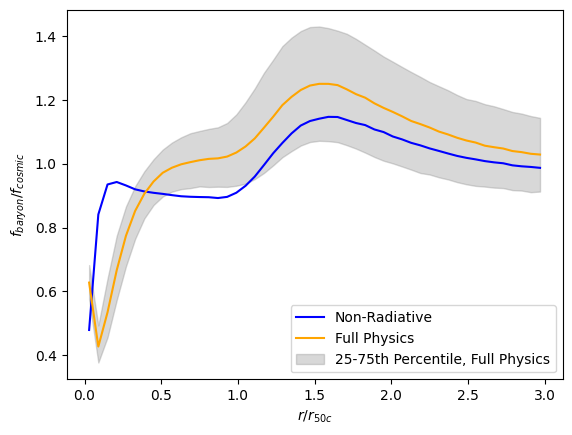

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import h5py


bins=np.linspace(0,3,51)
bin_center=0.5*(bins[1:]+bins[:-1]) 
f_baryon=fbar*(0.0494/0.316)/0.168#(profile_gas+profile_s)/(profile_dm+profile_gas+profile_s)/0.168
f_baryon_ad=fbar_ad*(0.0494/0.316)/0.168#(profile_gas_ad)/(profile_dm_ad+profile_gas_ad)/0.168
per=np.percentile(f_baryon[m50>10**4],(25,50,75),axis=0)
per_ad=np.percentile(f_baryon_ad[m50_ad>10**4],(25,50,75),axis=0)
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
#ax.plot(bin_center,f_baryon[100000],color='blue')
ax.plot(bin_center,per_ad[1],color='blue',label='Non-Radiative')
ax.plot(bin_center,per[1],color='orange',label='Full Physics')
ax.fill_between(bin_center,per[0],per[2],color='grey',alpha=0.3,label='25-75th Percentile, Full Physics')
ax.legend()
ax.set_xlabel(r'$r/r_{50c}$')
ax.set_ylabel(r'$f_{baryon}/f_{cosmic}$')

(array([7141, 7654, 1722,  396,   86,   18,    2,    0,    0,    1]), array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.]))


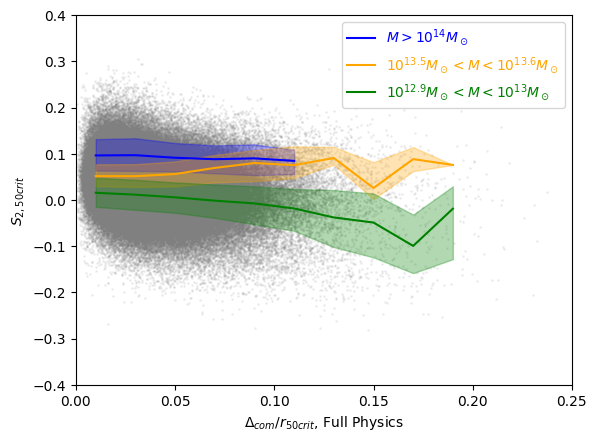

In [49]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)


r_com=np.sqrt(np.sum(delta_com**2,axis=1))
ax.scatter((r_com/r50)[(r_com<5)],S[(r_com<5)],s=1,alpha=0.1,color="gray")
#ax.scatter((r_com/r50)[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],S0[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],s=1,alpha=0.1,label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$')
#ax.scatter((r_com/r50)[(r_com<5)*(m50>10**2.9)*(m50<10**3)],S0[(r_com<5)*(m50>10**2.9)*(m50<10**3)],s=1,alpha=0.1,label=r'$10^{12.9}M_\odot<M<10^{13.0}M_\odot$')

bins=np.linspace(0,0.2,11)
bin=(0.5*(bins[1:]+bins[:-1]))
bin_count=np.digitize((r_com/r50)[(r_com<5)*(m50>10**4)],bins)
print(np.histogram(bin_count))
mean=np.zeros(len(bin))
per_75=np.zeros(len(bin))
per_25=np.zeros(len(bin))
for i in range(1,len(bins)):
    if len((r_com/r50)[(r_com<5)*(m50>10**4)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S[(r_com<5)*(m50>10**4)][bin_count==i],50)
    per_75[i-1]=np.percentile(S[(r_com<5)*(m50>10**4)][bin_count==i],75)
    per_25[i-1]=np.percentile(S[(r_com<5)*(m50>10**4)][bin_count==i],25)
ax.plot(bin[0:6],mean[0:6],color='blue',label=r'$M>10^{14}M_\odot$')
ax.fill_between(bin[0:6],per_25[0:6],per_75[0:6],color='blue',alpha=0.3)


bin_count=np.digitize((r_com/r50)[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],bins)
for i in range(1,len(bins)):
    if len((r_com/r50)[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)][bin_count==i],50)
    per_75[i-1]=np.percentile(S[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)][bin_count==i],75)
    per_25[i-1]=np.percentile(S[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)][bin_count==i],25)
ax.plot(bin,mean,color='orange',label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$')
ax.fill_between(bin,per_25,per_75,color='orange',alpha=0.3)

bin_count=np.digitize((r_com/r50)[(r_com<5)*(m50>10**2.9)*(m50<10**3)],bins)
for i in range(1,len(bins)):
    if len((r_com/r50)[(r_com<5)*(m50>10**2.9)*(m50<10**3)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S[(r_com<5)*(m50>10**2.9)*(m50<10**3)][bin_count==i],50)
    per_75[i-1]=np.percentile(S[(r_com<5)*(m50>10**2.9)*(m50<10**3)][bin_count==i],75)
    per_25[i-1]=np.percentile(S[(r_com<5)*(m50>10**2.9)*(m50<10**3)][bin_count==i],25)
ax.plot(bin,mean,color='green',label=r'$10^{12.9}M_\odot<M<10^{13}M_\odot$')
ax.fill_between(bin,per_25,per_75,color='green',alpha=0.3)

ax.legend(labelcolor='linecolor')
ax.set_xlabel(r"$\Delta_{com}/r_{50crit}$, Full Physics")
ax.set_ylabel(r"$S_{2,50crit}$")
ax.set_ybound(-0.4,0.4)
ax.set_xbound(0,0.25)

(array([9937, 7147,    0,  526,    0,   24,    4,    0,    2,    1]), array([1. , 1.6, 2.2, 2.8, 3.4, 4. , 4.6, 5.2, 5.8, 6.4, 7. ]))


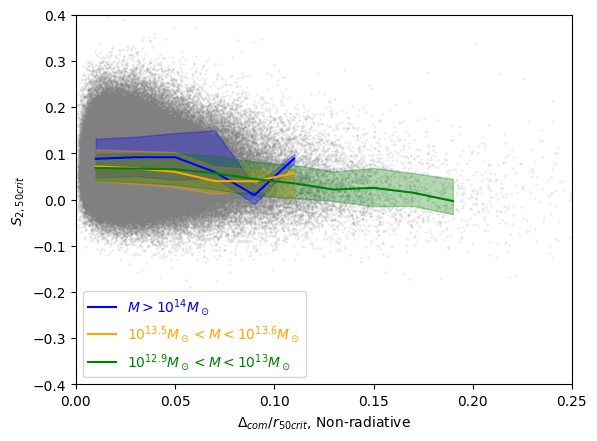

In [48]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)


ax.scatter((r_com_ad/r50_ad)[(r_com_ad<5)],S_ad[(r_com_ad<5)],s=1,alpha=0.1,color="gray")
#ax.scatter((r_com/r50)[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],S0[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],s=1,alpha=0.1,label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$')
#ax.scatter((r_com/r50)[(r_com<5)*(m50>10**2.9)*(m50<10**3)],S0[(r_com<5)*(m50>10**2.9)*(m50<10**3)],s=1,alpha=0.1,label=r'$10^{12.9}M_\odot<M<10^{13.0}M_\odot$')

bins=np.linspace(0,0.2,11)
bin=(0.5*(bins[1:]+bins[:-1]))
bin_count=np.digitize((r_com_ad/r50_ad)[(r_com_ad<5)*(m50_ad>10**4)],bins)
print(np.histogram(bin_count))
mean=np.zeros(len(bin))
per_75=np.zeros(len(bin))
per_25=np.zeros(len(bin))
for i in range(1,len(bins)):
    if len((r_com_ad/r50_ad)[(r_com_ad<5)*(m50_ad>10**4)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S_ad[(r_com_ad<5)*(m50_ad>10**4)][bin_count==i],50)
    per_75[i-1]=np.percentile(S_ad[(r_com_ad<5)*(m50_ad>10**4)][bin_count==i],75)
    per_25[i-1]=np.percentile(S_ad[(r_com_ad<5)*(m50_ad>10**4)][bin_count==i],25)
ax.plot(bin[0:6],mean[0:6],color='blue',label=r'$M>10^{14}M_\odot$')
ax.fill_between(bin[0:6],per_25[0:6],per_75[0:6],color='blue',alpha=0.3)


bin_count=np.digitize((r_com_ad/r50_ad)[(r_com_ad<5)*(m50_ad>10**3.5)*(m50_ad<10**3.6)],bins)
for i in range(1,len(bins)):
    if len((r_com_ad/r50_ad)[(r_com_ad<5)*(m50_ad>10**3.5)*(m50_ad<10**3.6)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S_ad[(r_com_ad<5)*(m50_ad>10**3.5)*(m50_ad<10**3.6)][bin_count==i],50)
    per_75[i-1]=np.percentile(S_ad[(r_com_ad<5)*(m50_ad>10**3.5)*(m50_ad<10**3.6)][bin_count==i],75)
    per_25[i-1]=np.percentile(S_ad[(r_com_ad<5)*(m50_ad>10**3.5)*(m50_ad<10**3.6)][bin_count==i],25)
ax.plot(bin[0:6],mean[0:6],color='orange',label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$')
ax.fill_between(bin[0:6],per_25[0:6],per_75[0:6],color='orange',alpha=0.3)

bin_count=np.digitize((r_com_ad/r50_ad)[(r_com_ad<5)*(m50_ad>10**2.9)*(m50_ad<10**3)],bins)
for i in range(1,len(bins)):
    if len((r_com_ad/r50_ad)[(r_com_ad<5)*(m50_ad>10**2.9)*(m50_ad<10**3)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S_ad[(r_com_ad<5)*(m50_ad>10**2.9)*(m50_ad<10**3)][bin_count==i],50)
    per_75[i-1]=np.percentile(S_ad[(r_com_ad<5)*(m50_ad>10**2.9)*(m50_ad<10**3)][bin_count==i],75)
    per_25[i-1]=np.percentile(S_ad[(r_com_ad<5)*(m50_ad>10**2.9)*(m50_ad<10**3)][bin_count==i],25)
ax.plot(bin,mean,color='green',label=r'$10^{12.9}M_\odot<M<10^{13}M_\odot$')
ax.fill_between(bin,per_25,per_75,color='green',alpha=0.3)

ax.legend(labelcolor='linecolor')
ax.set_xlabel(r"$\Delta_{com}/r_{50crit}$, Non-radiative")
ax.set_ylabel(r"$S_{2,50crit}$")
ax.set_ybound(-0.4,0.4)
ax.set_xbound(0,0.25)

(array([16956,     0,     0,     0,     0,     0,     0,     0,     0,
          64]), array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ]))


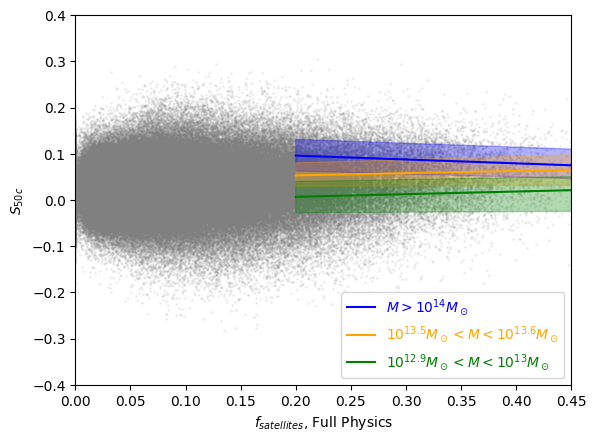

In [33]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)


r_com=np.sqrt(np.sum(delta_com**2,axis=1))
ax.scatter((f_sat)[(r_com<5)],S[(r_com<5)],s=1,alpha=0.1,color="gray")
#ax.scatter((r_com/r50)[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],S0[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],s=1,alpha=0.1,label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$')
#ax.scatter((r_com/r50)[(r_com<5)*(m50>10**2.9)*(m50<10**3)],S0[(r_com<5)*(m50>10**2.9)*(m50<10**3)],s=1,alpha=0.1,label=r'$10^{12.9}M_\odot<M<10^{13.0}M_\odot$')

bins=np.linspace(0,4,11)
bin=(0.5*(bins[1:]+bins[:-1]))
bin_count=np.digitize((f_sat)[(r_com<5)*(m50>10**4)],bins)
print(np.histogram(bin_count))
mean=np.zeros(len(bin))
per_75=np.zeros(len(bin))
per_25=np.zeros(len(bin))
for i in range(1,len(bins)):
    if len((f_sat)[(r_com<5)*(m50>10**4)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S[(r_com<5)*(m50>10**4)][bin_count==i],50)
    per_75[i-1]=np.percentile(S[(r_com<5)*(m50>10**4)][bin_count==i],75)
    per_25[i-1]=np.percentile(S[(r_com<5)*(m50>10**4)][bin_count==i],25)
ax.plot(bin,mean,color='blue',label=r'$M>10^{14}M_\odot$')
ax.fill_between(bin,per_25,per_75,color='blue',alpha=0.3)


bin_count=np.digitize((f_sat)[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)],bins)
for i in range(1,len(bins)):
    if len((f_sat)[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)][bin_count==i],50)
    per_75[i-1]=np.percentile(S[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)][bin_count==i],75)
    per_25[i-1]=np.percentile(S[(r_com<5)*(m50>10**3.5)*(m50<10**3.6)][bin_count==i],25)
ax.plot(bin,mean,color='orange',label=r'$10^{13.5}M_\odot<M<10^{13.6}M_\odot$')
ax.fill_between(bin,per_25,per_75,color='orange',alpha=0.3)

bin_count=np.digitize((f_sat)[(r_com<5)*(m50>10**2.9)*(m50<10**3)],bins)
for i in range(1,len(bins)):
    if len((r_com/r50)[(r_com<5)*(m50>10**2.9)*(m50<10**3)][bin_count==i])==0:
        mean[i-1]=-2
        per_75[i-1]=-2
        per_25[i-1]=-2
        continue
    mean[i-1]=np.percentile(S[(r_com<5)*(m50>10**2.9)*(m50<10**3)][bin_count==i],50)
    per_75[i-1]=np.percentile(S[(r_com<5)*(m50>10**2.9)*(m50<10**3)][bin_count==i],75)
    per_25[i-1]=np.percentile(S[(r_com<5)*(m50>10**2.9)*(m50<10**3)][bin_count==i],25)
ax.plot(bin,mean,color='green',label=r'$10^{12.9}M_\odot<M<10^{13}M_\odot$')
ax.fill_between(bin,per_25,per_75,color='green',alpha=0.3)

ax.legend(labelcolor='linecolor')
ax.set_xlabel(r"$f_{satellites}$, Full Physics")
ax.set_ylabel(r"$S_{50c}$")
ax.set_ybound(-0.4,0.4)
ax.set_xbound(0,0.45)